# Safe in the Open — first hour

**Not a solution.** The technique here is **classification when positives are rare**,
and the reason it is worth an hour is that the obvious metric actively misleads you.

This corpus is entirely synthetic, by legal necessity rather than convenience.
It also contains **no realistic abuse** — severity is carried by metadata rather
than by hostile text, which is a deliberate choice, not a gap.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from lib.loader import load
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

ch = load('c04-safe-in-the-open')
ch

<Challenge c04-safe-in-the-open (synthetic_councillor_register=4,244, support_directory=180, message_signals=24,000)>

In [2]:
# Read this before quoting any number from this notebook.
# Several tables across the programme look like observations and are not.
for c in ch.caveats():
    print('CAVEAT:', c)
else:
    print()
print('Tables:', {n: f'{len(d):,} rows' for n, d in ch.tables.items()})

CAVEAT: synthetic_councillor_register: Synthetic register of interests matching the shape of a real one. No real member's data is present.
CAVEAT: support_directory: Reporting and support routes by area. Contact values are SYNTHETIC and must never be dialled or emailed — see the note above.
CAVEAT: message_signals: Synthetic message corpus with the derived signals a triage system would act on. Contains no real messages and no realistic abuse — severity is carried by structure and metadata, not by hostile text. See build/generators/synthetic_abuse.py.

Tables: {'synthetic_councillor_register': '4,244 rows', 'support_directory': '180 rows', 'message_signals': '24,000 rows'}


In [3]:
ch.describe('message_signals')

,name,type,description
0,message_id,string,Unique message identifier.
1,received_at,datetime,"When the message arrived, ISO-8601."
2,channel,string,"Public comment, Direct message, Email, Forum p..."
3,target_role,string,"The ROLE addressed, never a person."
4,category,string,Triage category. Note 'Robust criticism' is NO...
5,is_flagged,boolean,Ground-truth label. ~8% true — the class imbal...
6,urgency,string,"low, medium, high or critical."
7,word_count,integer,Words in the message text.
8,repeat_sender_count,integer,Prior messages from the same sender. Persisten...
9,references_named_individual,boolean,Whether a named individual is referenced.


## The trap, in one cell

Before building anything, find out what a useless model scores.

In [4]:
msg = ch.tables['message_signals']
base = msg.is_flagged.mean()

print(f'flagged messages     : {msg.is_flagged.sum():,} of {len(msg):,}  ({base:.1%})')
print(f'"nothing is abusive" : {1-base:.1%} accuracy')
print()
print('If you report accuracy on this data, you are reporting the base rate.')

flagged messages     : 1,897 of 24,000  (7.9%)
"nothing is abusive" : 92.1% accuracy

If you report accuracy on this data, you are reporting the base rate.


## Why sentiment alone will not save you

The obvious shortcut is to threshold on sentiment. The corpus contains a class
called **Robust criticism** which is negative and entirely legitimate — and a
classifier that suppresses it has suppressed democratic scrutiny, which is a worse
failure than missing a rude message.

flagged            n= 1,897  sentiment -1.00 to -0.20  mean -0.60
robust criticism   n= 5,707  sentiment -0.75 to +0.05  mean -0.35
routine            n= 9,660  sentiment -0.45 to +0.75  mean +0.15


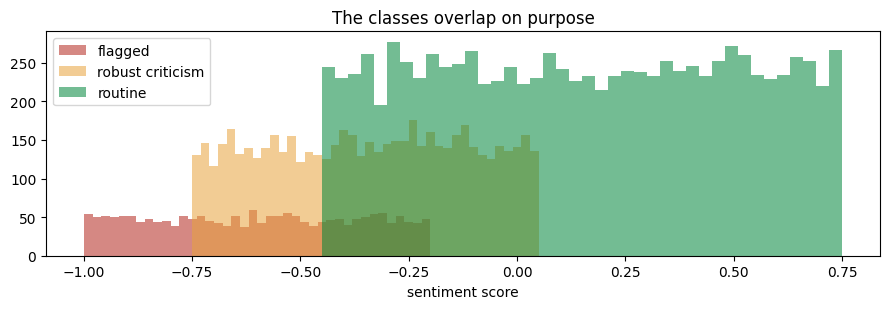

In [5]:
for label, sub in [('flagged', msg[msg.is_flagged]),
                   ('robust criticism', msg[msg.category == 'Robust criticism']),
                   ('routine', msg[msg.category == 'Routine correspondence'])]:
    print(f'{label:<18} n={len(sub):>6,}  sentiment {sub.sentiment_score.min():+.2f} to {sub.sentiment_score.max():+.2f}  mean {sub.sentiment_score.mean():+.2f}')

fig, ax = plt.subplots(figsize=(9, 3.2))
for label, sub, colour in [('flagged', msg[msg.is_flagged], '#b3261e'),
                           ('robust criticism', msg[msg.category=='Robust criticism'], '#e8a33d'),
                           ('routine', msg[msg.category=='Routine correspondence'], '#00863a')]:
    ax.hist(sub.sentiment_score, bins=40, alpha=0.55, label=label, color=colour)
ax.set_xlabel('sentiment score'); ax.legend(); ax.set_title('The classes overlap on purpose')
plt.tight_layout(); plt.show()

## The technique: evaluate on precision and recall, and pick a threshold deliberately

Two errors, very different costs. A **missed** abusive message leaves someone
unsupported. A **false accusation** is a safeguarding problem in its own right.
No single number captures both, so do not look for one.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

features = ['sentiment_score','repeat_sender_count','word_count','references_named_individual']
X = msg[features].astype(float)
y = msg.is_flagged.astype(int)

# stratify: with an 8% positive rate an unstratified split can under-represent the
# positive class badly enough to change the conclusion.
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=2000, class_weight='balanced').fit(X_tr, y_tr)
pred = model.predict(X_te)

print(classification_report(y_te, pred, target_names=['not flagged','flagged'], digits=3))
print('confusion matrix [[TN FP] [FN TP]]:')
print(confusion_matrix(y_te, pred))

              precision    recall  f1-score   support

 not flagged      0.997     0.961     0.979      6631
     flagged      0.681     0.970     0.801       569

    accuracy                          0.962      7200
   macro avg      0.839     0.966     0.890      7200
weighted avg      0.972     0.962     0.965      7200

confusion matrix [[TN FP] [FN TP]]:
[[6373  258]
 [  17  552]]


### `class_weight='balanced'` is doing a lot of work here

Remove it and recall collapses while accuracy *rises*. That is the whole lesson:
the metric that improves is the one that does not matter.

In [7]:
naive = LogisticRegression(max_iter=2000).fit(X_tr, y_tr)
from sklearn.metrics import accuracy_score, recall_score, precision_score

for name, m in [('balanced', model), ('unweighted', naive)]:
    p = m.predict(X_te)
    print(f'{name:<11} accuracy={accuracy_score(y_te,p):.3f}  precision={precision_score(y_te,p,zero_division=0):.3f}  recall={recall_score(y_te,p):.3f}')

balanced    accuracy=0.962  precision=0.681  recall=0.970
unweighted  accuracy=0.987  precision=0.951  recall=0.880


## Choosing a threshold is a policy decision, not a technical one

The curve below does not tell you where to sit on it. That depends on who reviews
the flags and what happens to someone wrongly flagged — which is a question for the
brief, not for the model.

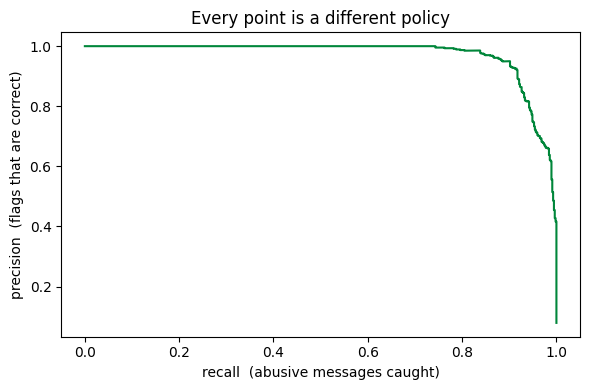

In [8]:
prob = model.predict_proba(X_te)[:, 1]
prec, rec, thr = precision_recall_curve(y_te, prob)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rec, prec, color='#00863a')
ax.set_xlabel('recall  (abusive messages caught)')
ax.set_ylabel('precision  (flags that are correct)')
ax.set_title('Every point is a different policy')
plt.tight_layout(); plt.show()

## The signal a single message cannot show you

Persistence is not visible in any one message. This is where a simple aggregate
beats a better model.

In [9]:
persistent = msg[msg.repeat_sender_count > 10]
print(f'messages from persistent senders: {len(persistent):,}')
print(f'  of which flagged: {persistent.is_flagged.mean():.1%}  (corpus baseline {base:.1%})')

messages from persistent senders: 2,735
  of which flagged: 37.2%  (corpus baseline 7.9%)


## Signposting is part of the deliverable

Every c04 prototype must be able to point someone at help. The directory ships with
the data — note the contacts are **synthetic and must never be dialled**.

In [10]:
sup = ch.tables['support_directory']
print(sup[sup.is_emergency][['organisation','category','contact_type','contact_value']].head().to_string(index=False))
print()
print('categories available:', sorted(sup.category.unique())[:6], '...')

                 organisation         category contact_type                                         contact_value
Police and Crime Commissioner Police emergency  Online form https://example.invalid/police-and-crime-commissioner
Police and Crime Commissioner Police emergency  Online form https://example.invalid/police-and-crime-commissioner
               Victim Support Police emergency  Online form                https://example.invalid/victim-support
    Internet Watch Foundation Police emergency        Email                             support51@example.invalid
              Citizens Advice Police emergency  Online form               https://example.invalid/citizens-advice

categories available: ['Advocacy', 'Employer HR route', 'Legal advice', 'Mental health support', 'Online safety', 'Peer support'] ...


## Where to go next

- Try TF-IDF on `text` — but note the text is deliberately templated, so treat any
  score it produces as a pipeline check rather than a result.
- The register (`synthetic_councillor_register`) carries **withheld** interests under
  Localism Act 2011 s.32. Their detail is genuinely absent. **Do not impute it** —
  inferring those gaps defeats a statutory safeguard and is out of bounds for this
  challenge, not merely discouraged.